Polynomial regression?


Import Libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Create Dataset:

In [2]:
data = {
    "Experience":[1,2,3,4,5,6,7,8,9,10],
    "Salary":[25000,30000,38000,50000,65000,83000,104000,128000,155000,185000]
}

df = pd.DataFrame(data)

In [3]:
print(df)

   Experience  Salary
0           1   25000
1           2   30000
2           3   38000
3           4   50000
4           5   65000
5           6   83000
6           7  104000
7           8  128000
8           9  155000
9          10  185000


In [4]:
df.head()

,Experience,Salary
0,1,25000
1,2,30000
2,3,38000
3,4,50000
4,5,65000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Experience  10 non-null     int64
 1   Salary      10 non-null     int64
dtypes: int64(2)
memory usage: 288.0 bytes


In [6]:
df.describe()

,Experience,Salary
count,10.00000,10.000000
mean,5.50000,86300.000000
std,3.02765,55333.433735
min,1.00000,25000.000000
25%,3.25000,41000.000000
50%,5.50000,74000.000000
75%,7.75000,122000.000000
max,10.00000,185000.000000


Separate X and y:

features:

In [7]:
X = df[['Experience']]

target:

In [8]:
y = df['Salary']

Polynomial Features:

In [9]:
poly = PolynomialFeatures(degree=2)

In [10]:
poly = PolynomialFeatures(degree=3)

In [11]:
X_poly = poly.fit_transform(X)

Train Test Split:

In [14]:
X_train,X_test,y_train,y_test=train_test_split(
X_poly,
y,
test_size=0.2,
random_state=42
)

Create Model:

In [15]:
model = LinearRegression()

Train Model:

In [16]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Coefficients:

In [17]:
print(model.coef_)

[   0.         -314.35914781 1789.09429136  -14.29185472]


Intercept:

In [18]:
print(model.intercept_)

23475.409836065788


Prediction:

In [19]:
y_pred=model.predict(X_test)

Evaluation:

In [20]:
mae=mean_absolute_error(y_test,y_pred)

mse=mean_squared_error(y_test,y_pred)

rmse=np.sqrt(mse)

r2=r2_score(y_test,y_pred)

New Prediction:

In [21]:
new_data=[[12]]

new_data_poly=poly.transform(new_data)

c:\Users\BEST LAPTOP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [22]:
prediction=model.predict(new_data_poly)

Visualization:

c:\Users\BEST LAPTOP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


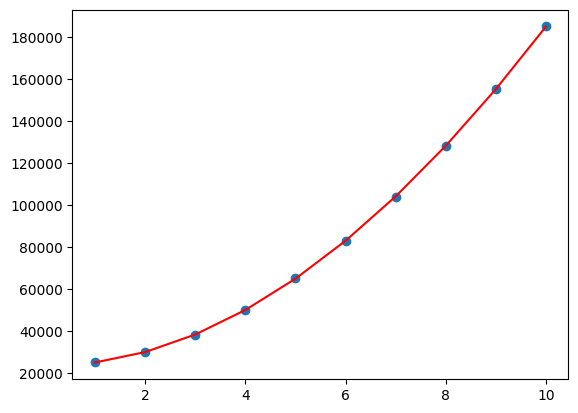

In [23]:
X_sort=np.sort(X.values,axis=0)

X_sort_poly=poly.transform(X_sort)

plt.scatter(X,y)

plt.plot(
X_sort,
model.predict(X_sort_poly),
color="red"
)

plt.show()